# K-mer sweep — relatórios de classificação dos `run.log`

Percorre a pasta `outputs/`, lê cada `run.log`, extrai a tabela do
*Classification report* (precision / recall / f1-score / support por classe,
mais accuracy e as médias macro/weighted) e monta os gráficos do varrimento
de `k`, com **média e desvio padrão sobre as repetições**.

Estruturas aceites:

- `outputs/<dataset>/k<N>/rep<R>/run.log` — sweep repetido (`REPEATS` repetições)
- `outputs/<dataset>/k<N>/run.log` — layout antigo, tratado como repetição 1


In [16]:
import os
import re
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# OUTPUTS_DIR = os.path.join("..", "outputs")   # ajuste se correr fora de notebooks/
OUTPUTS_DIR = os.path.join("/run/user/1000/gvfs/sftp:host=193.136.195.41,user=a61491/home/a61491/KEVOLVE/outputs")   # ajuste se correr fora de notebooks/

FIG_DIR = os.path.join("..", "outputs", "figs")
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option("display.width", 120)


## Estilo dos gráficos

Paleta categórica de ordem fixa (nunca ciclada), marcas finas, grelha recessiva.


In [8]:
# Paleta categórica — ordem fixa, atribuída por entidade (nunca por ranking)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ_HUE = "Blues"          # sequencial: um único tom, claro -> escuro
INK = "#0b0b0b"
INK_2 = "#52514e"
GRID = "#e3e2dd"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "600",
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "axes.labelsize": 10,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "font.size": 11,
    "figure.dpi": 120,
})


def color_map(keys):
    """Cor fixa por entidade: a mesma classe mantém a cor entre gráficos."""
    return {k: PALETTE[i % len(PALETTE)] for i, k in enumerate(sorted(keys))}


## Parsing dos `run.log`

O bloco `Classification report` tem linhas de classe com 4 números
(precision, recall, f1-score, support), a linha `accuracy` com 2
(accuracy, support) e as linhas `macro avg` / `weighted avg` com 4.
O rótulo pode conter espaços, por isso os números são lidos a partir do fim.


In [17]:
NUM = re.compile(r"^\d+(?:\.\d+)?$")


def _parse_report_block(lines):
    """Converte as linhas de um 'Classification report' em registos."""
    rows = []
    for line in lines:
        if not line.strip():
            continue
        toks = line.split()
        if toks[0] in ("precision", "Predictions", "KEVOLVE:"):
            continue
        nums = []
        while toks and NUM.match(toks[-1]):
            nums.append(float(toks.pop()))
        nums.reverse()
        label = " ".join(toks)
        if not label or not nums:
            continue
        if label == "accuracy" and len(nums) == 2:
            rows.append({"label": "accuracy", "kind": "overall",
                         "precision": np.nan, "recall": np.nan,
                         "f1": nums[0], "support": nums[1]})
        elif len(nums) == 4:
            kind = "avg" if label.endswith("avg") else "class"
            rows.append({"label": label, "kind": kind,
                         "precision": nums[0], "recall": nums[1],
                         "f1": nums[2], "support": nums[3]})
    return rows


def parse_run_log(path):
    """Extrai k, dataset, tempo de execução e o classification report de um run.log."""
    with open(path, "r", errors="replace") as f:
        text = f.read()

    # <dataset>/k<N>[/rep<R>]/run.log — o nível rep é opcional
    parts = os.path.relpath(os.path.dirname(path), OUTPUTS_DIR).split(os.sep)
    repeat = 1
    if parts and parts[-1].startswith("rep"):
        try:
            repeat = int(parts[-1][3:])
        except ValueError:
            pass
        parts = parts[:-1]
    kdir = parts[-1] if parts else ""
    dataset = parts[-2] if len(parts) >= 2 else (parts[0] if parts else "?")

    m = re.search(r"KEVOLVE:\s*k\s*=\s*(\d+)", text)
    if m:
        k = int(m.group(1))
    else:
        m = re.search(r"k(\d+)", kdir)
        k = int(m.group(1)) if m else np.nan

    m = re.search(r"^Time:\s*([\d.]+)", text, flags=re.M)
    seconds = float(m.group(1)) if m else np.nan

    m = re.search(r"Identified solutions \((\d+)\)", text)
    n_solutions = int(m.group(1)) if m else np.nan

    # Último classification report do ficheiro (modo testing)
    idx = text.rfind("Classification report")
    if idx == -1:
        return []
    block = text[idx:].splitlines()[1:]
    stop = next((i for i, l in enumerate(block) if l.startswith("Predictions saved")),
                len(block))

    recs = []
    for row in _parse_report_block(block[:stop]):
        row.update(dataset=dataset, k=k, repeat=repeat, seconds=seconds,
                   n_solutions=n_solutions, path=path)
        recs.append(row)
    return recs


log_paths = sorted(glob.glob(os.path.join(OUTPUTS_DIR, "**", "run.log"), recursive=True))
print(f"{len(log_paths)} ficheiros run.log encontrados")

records = [r for p in log_paths for r in parse_run_log(p)]
df = pd.DataFrame(records)
df = df.sort_values(["dataset", "k", "repeat", "kind", "label"]).reset_index(drop=True)

n_reps = df.groupby(["dataset", "k"]).repeat.nunique()
print(f"repetições por (dataset, k): min={n_reps.min()}, max={n_reps.max()}")
df.head(12)


37 ficheiros run.log encontrados


,label,kind,precision,recall,f1,support,dataset,k,seconds,n_solutions,path
0,macro avg,avg,0.44,0.25,0.20,4765.0,denv,5,184.325310,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."
1,weighted avg,avg,0.68,0.19,0.25,4765.0,denv,5,184.325310,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."
2,type1_reducted,class,0.97,0.13,0.23,2247.0,denv,5,184.325310,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."
3,type2_reducted,class,0.68,0.28,0.40,1432.0,denv,5,184.325310,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."
4,type3_reducted,class,0.08,0.18,0.11,948.0,denv,5,184.325310,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."
5,type4_reducted,class,0.03,0.39,0.06,138.0,denv,5,184.325310,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."
6,accuracy,overall,NaN,NaN,0.19,4765.0,denv,5,184.325310,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."
7,macro avg,avg,0.76,0.46,0.42,4765.0,denv,6,175.517076,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."
8,weighted avg,avg,0.77,0.50,0.50,4765.0,denv,6,175.517076,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."
9,type1_reducted,class,0.97,0.56,0.71,2247.0,denv,6,175.517076,10,"/run/user/1000/gvfs/sftp:host=193.136.195.41,u..."


## Tabelas derivadas

In [18]:
# Uma linha por (dataset, k, repetição, métrica global)
runs = (df[df.kind.isin(["overall", "avg"])]
        .pivot_table(index=["dataset", "k", "repeat"], columns="label", values="f1")
        .rename(columns={"macro avg": "macro avg F1", "weighted avg": "weighted avg F1"})
        .reset_index())

OVERALL_METRICS = [m for m in ("accuracy", "macro avg F1", "weighted avg F1")
                   if m in runs.columns]

# Média e desvio padrão sobre as repetições (desvio amostral, ddof=1)
overall = (runs.groupby(["dataset", "k"])[OVERALL_METRICS]
           .agg(["mean", "std", "count"]))
overall.columns = [f"{metric}|{stat}" for metric, stat in overall.columns]
overall = overall.reset_index()

meta = (df.groupby(["dataset", "k"])
        .agg(seconds_mean=("seconds", "mean"), seconds_std=("seconds", "std"),
             n_solutions=("n_solutions", "first"))
        .reset_index())
overall = overall.merge(meta, on=["dataset", "k"])

# Por classe: média e desvio de precision / recall / f1 sobre as repetições
per_class = (df[df.kind == "class"]
             .groupby(["dataset", "k", "label"])
             .agg(precision_mean=("precision", "mean"), precision_std=("precision", "std"),
                  recall_mean=("recall", "mean"), recall_std=("recall", "std"),
                  f1_mean=("f1", "mean"), f1_std=("f1", "std"),
                  support=("support", "first"), n=("f1", "count"))
             .reset_index())

display(overall.round(4))
per_class.round(4)

,dataset,k,accuracy,macro avg F1,weighted avg F1,seconds,n_solutions
0,denv,5,0.19,0.20,0.25,184.325310,10
1,denv,6,0.50,0.42,0.50,175.517076,10
2,denv,7,0.49,0.46,0.59,484.886785,10
3,denv,8,0.36,0.46,0.27,908.671103,10
4,denv,9,0.01,0.01,0.01,2612.135575,10
5,denv,10,0.70,0.55,0.73,3363.640452,10
6,hiv,5,0.86,0.85,0.87,1417.386531,8
7,hiv,6,0.53,0.39,0.45,995.014227,10
8,hiv,7,0.85,0.82,0.85,615.274806,10
9,hiv,8,0.21,0.18,0.20,1612.702277,10


k                           5     6     7     8     9     10
dataset label                                               
denv    type1_reducted    0.23  0.71  0.64  0.01  0.01  0.99
        type2_reducted    0.40  0.22  0.51  0.43  0.00  0.26
        type3_reducted    0.11  0.46  0.66  0.55  0.01  0.95
        type4_reducted    0.06  0.29  0.03  0.85  0.01  0.01
hiv     HIV1_A            0.89  0.63  0.92  0.23  0.62  0.97
        HIV1_B            0.91  0.16  0.88  0.01  0.05  0.94
        HIV1_C            0.92  0.84  0.84  0.42  0.49  0.99
        HIV1_D            0.76  0.49  0.83  0.37  0.49  0.92
        HIV1_F            0.64  0.13  0.74  0.00  0.00  0.92
        HIV1_G            0.97  0.11  0.73  0.05  0.62  0.95
mkpx    II_reducted       0.99  0.99  0.99  0.99  0.99  0.99
        I_reducted        0.89  0.95  0.94  0.91  0.92  0.92
sars    Alpha_reducted    0.00  0.41  0.27  0.96  0.00  1.00
        Beta_reducted     0.00  0.41  0.00  0.02  0.02  0.99
        Delta_reducted    0.06  0.24  0.96  0.87  0.00  0.99
        Epsilon_reducted  0.00  0.89  0.24  0.00  0.17  1.00
        Eta_reducted      0.01  0.05  0.00  0.02  0.05  0.96
        Gamma_reducted    0.30  0.11  0.00  0.28  0.58  0.99
        Iota_reducted     0.00  0.59  0.00  0.01  0.00  0.99
        Kappa_reducted    0.00  0.57  0.00  0.00  0.00  0.16
        Lambda_reducted   0.00  0.92  0.00  0.00  0.00  0.92
        Omicron_reducted  0.00  0.98  0.16  0.89  0.83  1.00

## 1. Varrimento de k — métricas globais

Uma faceta por dataset, um eixo só. Accuracy e as médias macro/weighted partilham
a escala 0–1, por isso vivem no mesmo gráfico.


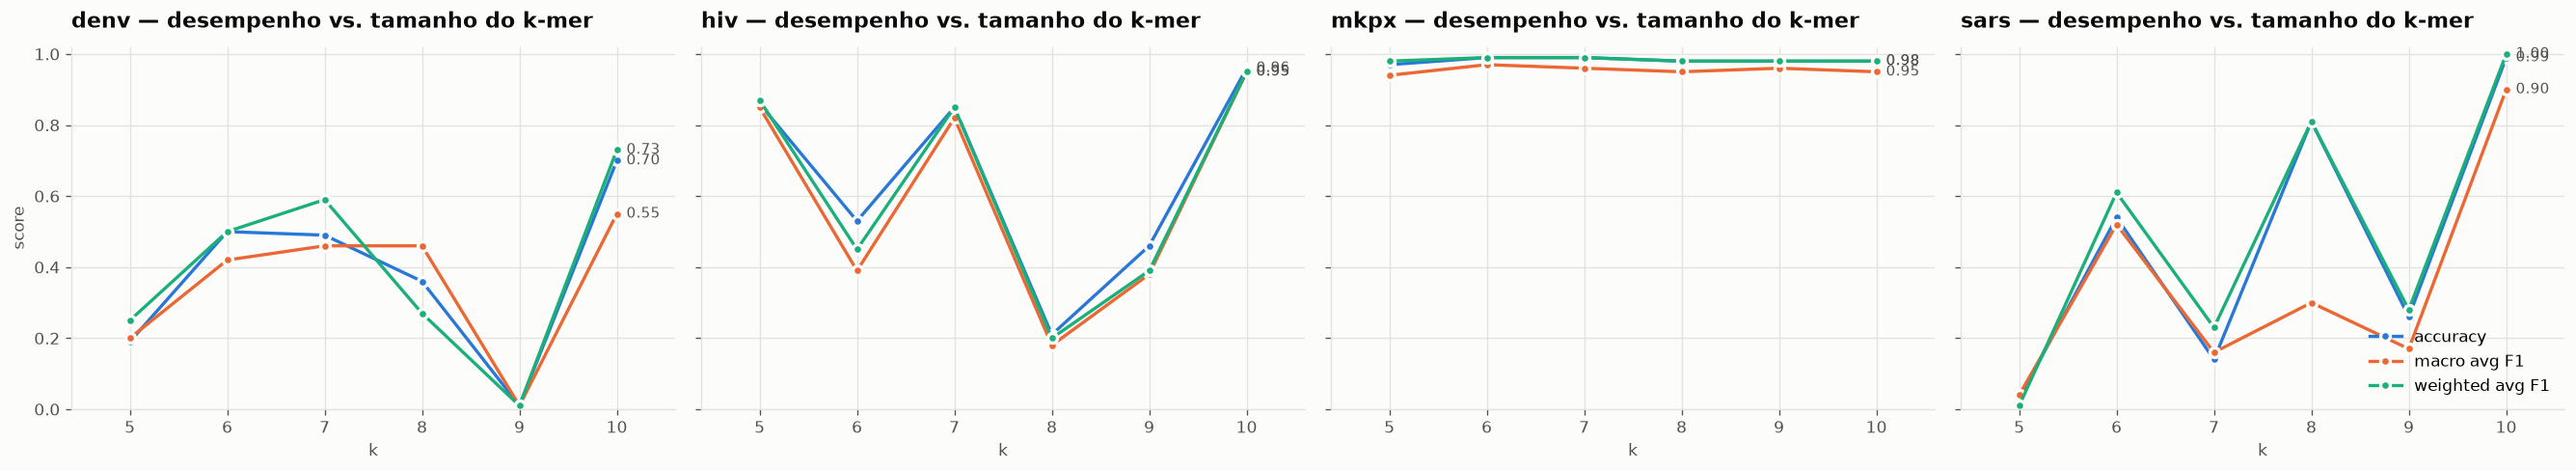

In [19]:
def sweep_overall(overall, metrics=None):
    """Linha = média sobre as repetições; banda = ±1 desvio padrão."""
    metrics = metrics or OVERALL_METRICS
    cmap = color_map(metrics)
    datasets = sorted(overall.dataset.unique())
    fig, axes = plt.subplots(1, len(datasets), figsize=(5.6 * len(datasets), 4.2),
                             squeeze=False, sharey=True)

    for ax, ds in zip(axes[0], datasets):
        sub = overall[overall.dataset == ds].sort_values("k")
        for metric in metrics:
            mean, std = sub[f"{metric}|mean"], sub[f"{metric}|std"].fillna(0)
            ax.fill_between(sub.k, mean - std, mean + std,
                            color=cmap[metric], alpha=0.15, linewidth=0)
            ax.plot(sub.k, mean, marker="o", color=cmap[metric], label=metric,
                    markeredgecolor=SURFACE, markeredgewidth=2)
            # rótulo direto no último ponto (<= 4 séries)
            ax.annotate(f"{mean.iloc[-1]:.2f}±{std.iloc[-1]:.2f}",
                        (sub.k.iloc[-1], mean.iloc[-1]),
                        xytext=(6, 0), textcoords="offset points",
                        va="center", fontsize=9, color=INK_2)
        n = int(sub[f"{metrics[0]}|count"].max())
        ax.set_title(f"{ds} — desempenho vs. tamanho do k-mer\nmédia ± 1 dp de {n} repetições")
        ax.set_xlabel("k")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_ylim(0, 1.02)
        ax.margins(x=0.16)
    axes[0][0].set_ylabel("score")
    axes[0][-1].legend(loc="lower right")
    fig.tight_layout()
    return fig


fig = sweep_overall(overall)
fig.savefig(os.path.join(FIG_DIR, "kmer_sweep_overall.png"), bbox_inches="tight")
plt.show()

## 2. Varrimento de k — F1 por classe

A cor segue a classe (entidade), não o ranking: a mesma classe mantém a cor
em todas as facetas e gráficos.


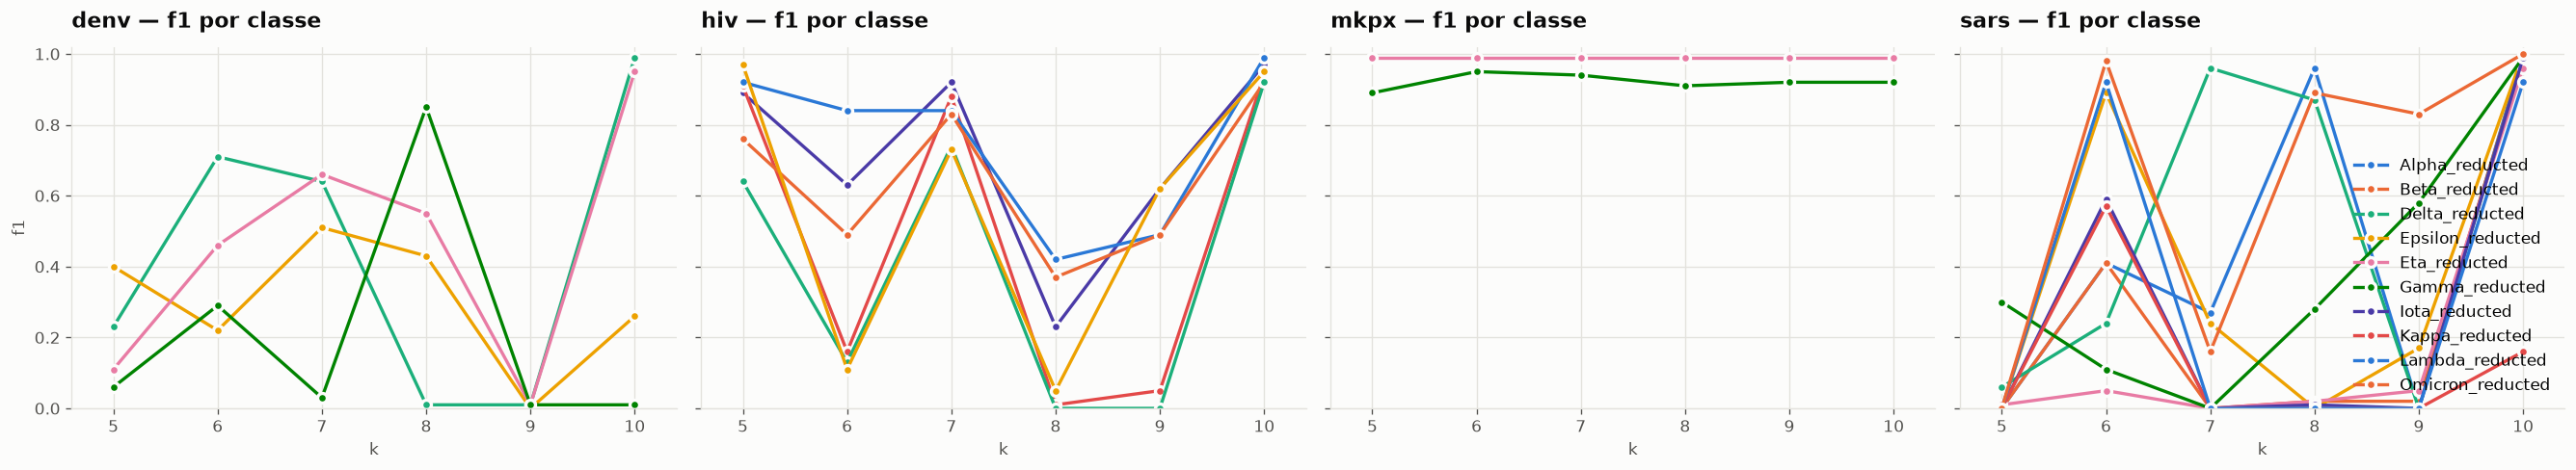

In [20]:
def sweep_per_class(per_class, metric="f1"):
    """Uma linha por classe: média sobre as repetições, banda de ±1 desvio padrão."""
    cmap = color_map(per_class.label.unique())
    datasets = sorted(per_class.dataset.unique())
    fig, axes = plt.subplots(1, len(datasets), figsize=(5.6 * len(datasets), 4.2),
                             squeeze=False, sharey=True)

    for ax, ds in zip(axes[0], datasets):
        sub = per_class[per_class.dataset == ds]
        for label, g in sub.groupby("label"):
            g = g.sort_values("k")
            mean, std = g[f"{metric}_mean"], g[f"{metric}_std"].fillna(0)
            ax.fill_between(g.k, mean - std, mean + std,
                            color=cmap[label], alpha=0.15, linewidth=0)
            ax.plot(g.k, mean, marker="o", color=cmap[label], label=label,
                    markeredgecolor=SURFACE, markeredgewidth=2)
        n = int(sub.n.max())
        ax.set_title(f"{ds} — {metric} por classe\nmédia ± 1 dp de {n} repetições")
        ax.set_xlabel("k")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_ylim(0, 1.02)
        ax.margins(x=0.08)
    axes[0][0].set_ylabel(metric)
    axes[0][-1].legend(loc="lower right", ncol=1)
    fig.tight_layout()
    return fig


fig = sweep_per_class(per_class, "f1")
fig.savefig(os.path.join(FIG_DIR, "kmer_sweep_per_class_f1.png"), bbox_inches="tight")
plt.show()

## 3. Heatmap classe × k

Escala sequencial de um único tom (claro → escuro) para magnitude;
cada célula traz o valor escrito, por isso a cor nunca é o único canal.


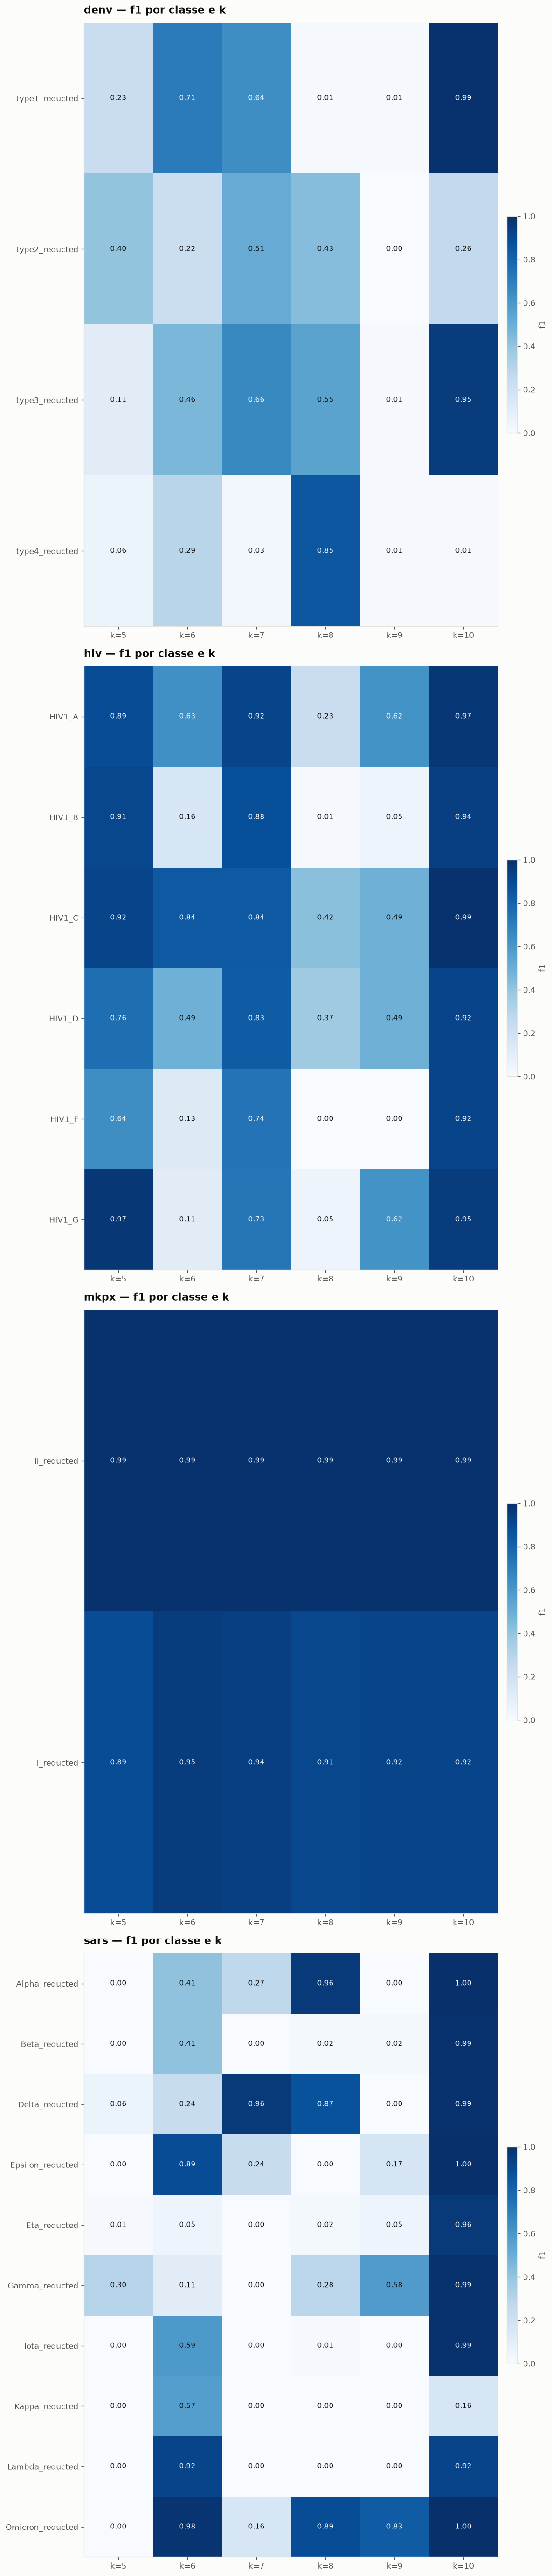

In [21]:
def heatmap_per_class(per_class, dataset=None, metric="f1"):
    """Cor = média; o texto da célula traz média e desvio padrão."""
    datasets = [dataset] if dataset else sorted(per_class.dataset.unique())
    fig, axes = plt.subplots(len(datasets), 1, squeeze=False,
                             figsize=(1.3 * per_class.k.nunique() + 4,
                                      2.2 + 0.55 * per_class.label.nunique() * len(datasets)))

    for ax, ds in zip(axes[:, 0], datasets):
        sub = per_class[per_class.dataset == ds]
        m = sub.pivot_table(index="label", columns="k", values=f"{metric}_mean").sort_index()
        s = (sub.pivot_table(index="label", columns="k", values=f"{metric}_std")
             .reindex(index=m.index, columns=m.columns))
        im = ax.imshow(m.values, cmap=SEQ_HUE, vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(m.shape[1]), [f"k={c}" for c in m.columns])
        ax.set_yticks(range(m.shape[0]), m.index)
        ax.set_title(f"{ds} — {metric} por classe e k (média ± dp)")
        ax.grid(False)
        for i in range(m.shape[0]):
            for j in range(m.shape[1]):
                v = m.values[i, j]
                if np.isnan(v):
                    continue
                d = s.values[i, j]
                text = f"{v:.2f}" if np.isnan(d) else f"{v:.2f}\n±{d:.2f}"
                ax.text(j, i, text, ha="center", va="center", fontsize=8.5,
                        linespacing=1.3, color="#ffffff" if v > 0.6 else INK)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label=f"{metric} (média)")
    fig.tight_layout()
    return fig


fig = heatmap_per_class(per_class)
fig.savefig(os.path.join(FIG_DIR, "kmer_heatmap_per_class.png"), bbox_inches="tight")
plt.show()

## 4. Custo de execução vs. k

Gráfico separado — escala de tempo não partilha eixo com scores.


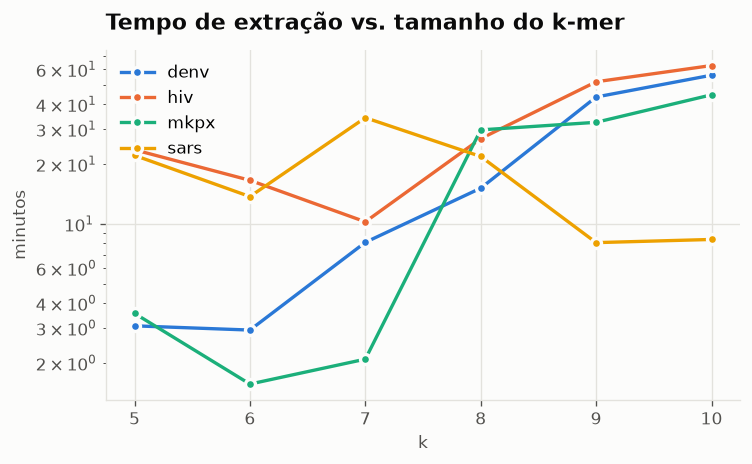

In [22]:
def sweep_runtime(overall):
    sub = overall.dropna(subset=["seconds_mean"])
    if sub.empty:
        print("Sem linhas 'Time:' nos run.log")
        return None
    cmap = color_map(sub.dataset.unique())
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    for ds, g in sub.groupby("dataset"):
        g = g.sort_values("k")
        mean, std = g.seconds_mean / 60, g.seconds_std.fillna(0) / 60
        ax.fill_between(g.k, mean - std, mean + std, color=cmap[ds], alpha=0.15, linewidth=0)
        ax.plot(g.k, mean, marker="o", color=cmap[ds], label=ds,
                markeredgecolor=SURFACE, markeredgewidth=2)
    ax.set_title("Tempo de extração vs. tamanho do k-mer\nmédia ± 1 dp das repetições")
    ax.set_xlabel("k")
    ax.set_ylabel("minutos")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_yscale("log")
    if sub.dataset.nunique() > 1:
        ax.legend(loc="upper left")
    fig.tight_layout()
    return fig


fig = sweep_runtime(overall)
if fig:
    fig.savefig(os.path.join(FIG_DIR, "kmer_sweep_runtime.png"), bbox_inches="tight")
    plt.show()

## 5. Tabela completa

Vista tabular de tudo o que foi extraído — a alternativa não-visual aos gráficos.


In [23]:
# Tabela longa: cada repetição de cada run
raw = df[["dataset", "k", "repeat", "label", "kind",
          "precision", "recall", "f1", "support", "seconds"]].round(4)
raw.to_csv(os.path.join(FIG_DIR, "kmer_sweep_reports.csv"), index=False)

# Tabela resumo: média ± desvio padrão por (dataset, k, classe)
summary = (df.groupby(["dataset", "k", "label", "kind"])
           .agg(n=("f1", "count"),
                precision_mean=("precision", "mean"), precision_std=("precision", "std"),
                recall_mean=("recall", "mean"), recall_std=("recall", "std"),
                f1_mean=("f1", "mean"), f1_std=("f1", "std"),
                support=("support", "first"))
           .round(4))
summary.to_csv(os.path.join(FIG_DIR, "kmer_sweep_summary.csv"))
summary

precision  recall    f1   support
dataset k  label                                              
denv    5  accuracy                NaN     NaN  0.19    4765.0
           macro avg              0.44    0.25  0.20    4765.0
           type1_reducted         0.97    0.13  0.23    2247.0
           type2_reducted         0.68    0.28  0.40    1432.0
           type3_reducted         0.08    0.18  0.11     948.0
...                                ...     ...   ...       ...
sars    10 Lambda_reducted        0.86    0.98  0.92     339.0
           Omicron_reducted       1.00    0.99  1.00  106204.0
           accuracy                NaN     NaN  0.99  334066.0
           macro avg              0.88    0.99  0.90  334066.0
           weighted avg           1.00    0.99  1.00  334066.0

[204 rows x 4 columns]